# 00 · The setting, the rule, and the panel

**What this notebook answers.** What is being measured, what the regulation actually
says, and what the assembled panel looks like. It ends with the one structural fact —
truncation at the reporting threshold — that constrains everything in notebooks 01–04.

---

## The setting

The **Greenhouse Gas Reporting Program** (GHGRP, 40 CFR Part 98) requires a US facility
to report its emissions annually if it emits **25,000 tCO₂e or more**. Reports are
published facility by facility. This is a *disclosure* mandate, not an emissions cap:
nothing about the rule requires a facility to abate. Whatever a facility does in
response is therefore a response to the cost of being observed.

## The rule that makes identification possible — 40 CFR 98.2(i)

A reporter **may stop reporting** if either condition holds:

| route | condition | waiting period |
|---|---|---|
| A | emissions below **25,000** tCO₂e | **5 consecutive years** |
| B | emissions below **15,000** tCO₂e | **3 consecutive years** |

and must resume if it ever reaches 25,000 again.

This is the analytical backbone of the project. It converts the reporting obligation
from a static status into a **decision with a known price and a known waiting time**: a
facility that no longer wants to be observed has a legal, costless exit, but only after
it has stayed under the line long enough. Notebook 03 uses exactly this.

## Roadmap

| notebook | question |
|---|---|
| **00** (this one) | what the data and the rule are |
| 01 | why the two obvious research designs fail |
| 02 | do firms manipulate reported emissions? (eight tests) |
| 03 | do firms exit — and what does that bound the cost at? |
| 04 | is compliance explained by enforcement? |

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
warnings.filterwarnings("ignore")
pd.set_option("display.width", 170); pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False})

sys.path.insert(0, ".")
from ghgrp_load import load_cached

OUT = Path("output")
de = load_cached()

print(f"{len(de):,} facility-years | {de.FacilityId.nunique():,} facilities | "
      f"{de.year.min()}–{de.year.max()}")
print(f"always-covered share: {de.always_covered.mean():.1%}   CEMS: {de.cems.mean():.1%}")
print(f"FRS Id coverage (the EPA cross-program key): {de.FRSId.notna().mean():.1%}")

94,378 facility-years | 8,778 facilities | 2010–2023
always-covered share: 36.8%   CEMS: 4.2%
FRS Id coverage (the EPA cross-program key): 97.8%


### How the panel is built, and one decision worth flagging

The panel stacks the **per-year** GHGRP workbooks rather than EPA's convenient
multi-year file. Three reasons, all discovered the hard way:

1. the multi-year workbook starts in **2011**, losing a year;
2. its subpart column is stamped *"Latest Reported"* — time-invariant, so a facility
   that changed subparts is misclassified in every earlier year;
3. it drops the **CEMS** flag, which is the only marker of instrument-measured rather
   than self-computed emissions.

Sheet names change (`Direct Emitters` → `Direct Point Emitters` in 2018) and header rows
move, so the loader discovers both. Subpart-W sheets are **excluded by default** — they
are basin-level, a different unit of observation, and merging them silently duplicates
facility-years.

### Two groups used throughout

- **threshold-bound** — reports only because it exceeds 25,000, so it disappears from
  the data when it falls below;
- **always-covered** — subparts **D, F, G, H, HH** (power generation, aluminium, ammonia,
  cement, landfills) report **regardless of emissions level**.

Notebook 01 shows the second group cannot serve as a counterfactual, but *can* serve as
a placebo.

In [2]:
tab = (de.groupby("year")
         .agg(facilities=("FacilityId", "nunique"),
              entries=("enters", "sum"), exits=("exits", "sum"),
              total_Mt=("emissions", lambda s: s.sum() / 1e6),
              median_em=("emissions", "median"),
              share_lt25k=("emissions", lambda s: (s < 25000).mean()),
              share_lt15k=("emissions", lambda s: (s < 15000).mean()))
         .round(3))
display(tab)
tab.to_csv(OUT / "t1_panel_by_year.csv")

print("\nyears observed per facility:")
display(de.groupby("FacilityId").year.nunique().value_counts().sort_index()
          .to_frame("facilities").T)
print(f"balanced (all {de.year.nunique()} years): "
      f"{(de.groupby('FacilityId').year.nunique() == de.year.nunique()).mean():.1%}")
print(f"facilities with a gap (left and came back): "
      f"{de.groupby('FacilityId').gap_after.any().mean():.1%}")

,facilities,entries,exits,total_Mt,median_em,share_lt25k,share_lt15k
year,,,,,,,
2010,6297,0,41,3196.572,70075.000,0.121,0.085
2011,6907,668,32,3207.583,67478.298,0.140,0.087
2012,7102,225,130,3058.076,63556.011,0.163,0.094
2013,7191,232,113,3073.214,60206.424,0.181,0.102
2014,7349,259,257,3084.069,57855.192,0.188,0.110
2015,7242,171,756,2939.444,58465.660,0.180,0.094
2016,6572,115,191,2804.145,65538.309,0.160,0.082
2017,6488,132,92,2734.723,65455.004,0.158,0.081
2018,6581,159,158,2778.824,67984.244,0.145,0.071



years observed per facility:


year,1,2,3,4,5,6,7,8,9,10,11,12,13,14
facilities,202,240,324,298,480,620,279,235,227,246,269,227,441,4690


balanced (all 14 years): 53.4%
facilities with a gap (left and came back): 2.4%


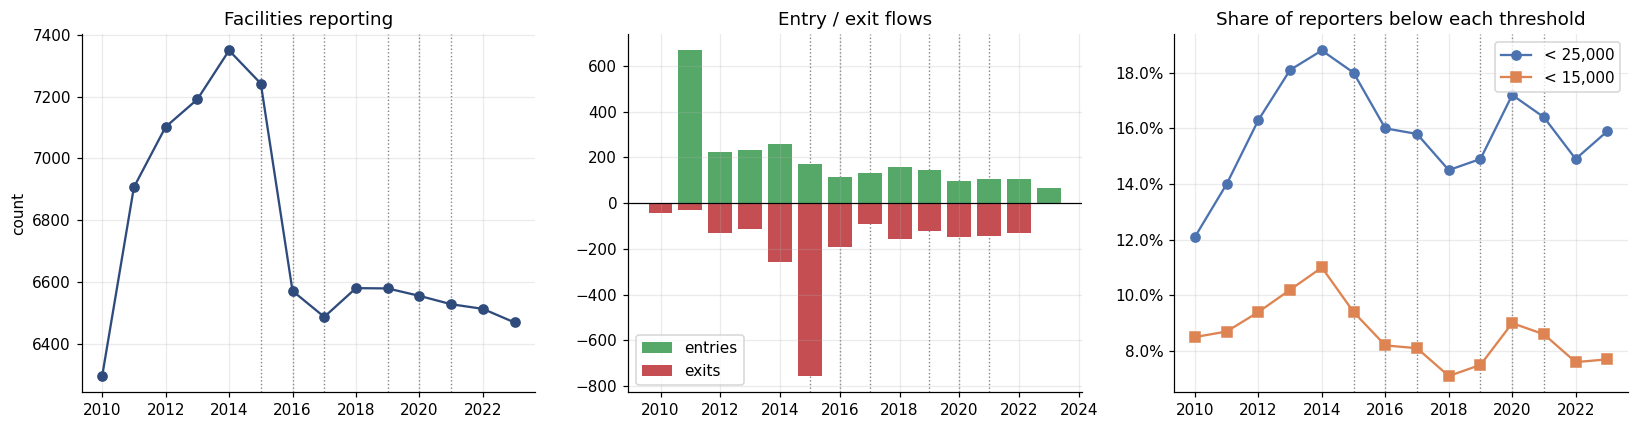

In [3]:
EVENTS = {2015: "CPP finalized", 2016: "SCOTUS stay", 2017: "Paris announcement",
          2019: "ACE repeals CPP", 2020: "Paris exit", 2021: "US rejoins"}


def mark(ax):
    for y in EVENTS:
        if de.year.min() <= y <= de.year.max():
            ax.axvline(y, color="gray", ls=":", lw=.9, zorder=0)


fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(tab.index, tab.facilities, "o-", color="#2F4B7C"); mark(ax[0])
ax[0].set_title("Facilities reporting"); ax[0].set_ylabel("count")

ax[1].bar(tab.index, tab.entries, color="#55A868", label="entries")
ax[1].bar(tab.index, -tab.exits, color="#C44E52", label="exits")
ax[1].axhline(0, color="k", lw=.8); mark(ax[1]); ax[1].legend()
ax[1].set_title("Entry / exit flows")

ax[2].plot(tab.index, tab.share_lt25k, "o-", label="< 25,000", color="#4C72B0")
ax[2].plot(tab.index, tab.share_lt15k, "s-", label="< 15,000", color="#DD8452")
ax[2].yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); mark(ax[2]); ax[2].legend()
ax[2].set_title("Share of reporters below each threshold")
plt.tight_layout(); plt.savefig(OUT / "f1_panel_structure.png", bbox_inches="tight"); plt.show()

**What I take from this.** The reporting population is remarkably stable — roughly
8,000 facilities every year, no trend, no visible break at any of the marked policy
events. Two things do stand out:

- a **spike in exits in 2015–16**. My first hypothesis was a loader bug (the 2016
  workbook was restructured); I ruled that out — only 4 of the 756 exiting facilities
  appear in the 2016 file. My second was a rule change; there wasn't one. It is the
  **2014–16 oil price collapse**, which hit the onshore petroleum and gas facilities
  that make up much of the smaller end of the panel. Worth remembering when reading any
  exit result: notebook 03 therefore leans on *within-year* comparisons of eligible vs
  ineligible facilities rather than on the exit time series.
- **between 12% and 19% of reporters sit below 25,000 in any given year** (12.1% in 2010,
  peaking at 18.8% in 2014, 16.9% in 2023), and the share is stable with no trend. Those
  are facilities working through the 98.2(i) waiting period, plus a smaller group that
  keeps reporting when it need not (notebook 04 §3).

,p10,p25,p50,p75,p90
year,,,,,
2010,19891.0,34584.0,70075.0,207922.0,979304.0
2011,18552.0,33365.0,67478.0,189573.0,887466.0
2012,16040.0,31763.0,63556.0,179247.0,851538.0
2013,14639.0,29811.0,60206.0,167373.0,828675.0
2014,13293.0,29181.0,57855.0,164355.0,823376.0
2015,16063.0,29949.0,58466.0,166845.0,823795.0
2016,17355.0,31793.0,65538.0,187041.0,894017.0
2017,18237.0,32613.0,65455.0,184295.0,866315.0
2018,20304.0,33348.0,67984.0,191822.0,902129.0


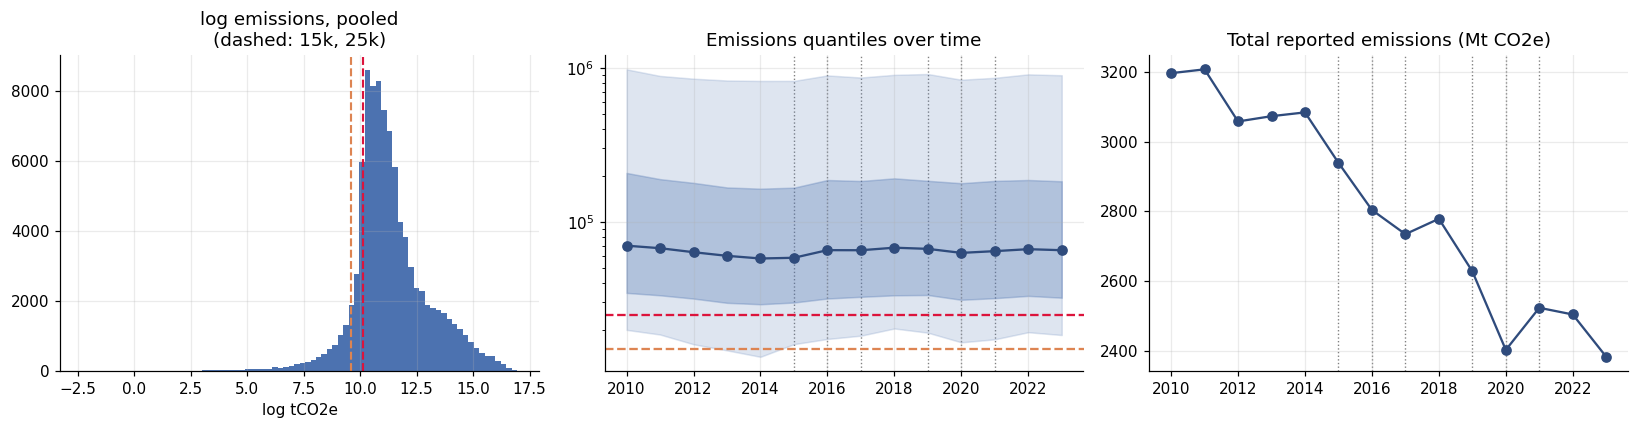

In [4]:
q = (de.groupby("year").emissions.quantile([.1, .25, .5, .75, .9]).unstack().round(0))
q.columns = [f"p{int(c*100)}" for c in q.columns]
display(q)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(de.log_em.dropna(), bins=80, color="#4C72B0")
for t, c in [(15000, "#DD8452"), (25000, "crimson")]:
    ax[0].axvline(np.log(t), color=c, ls="--", lw=1.4)
ax[0].set_title("log emissions, pooled\n(dashed: 15k, 25k)"); ax[0].set_xlabel("log tCO2e")

ax[1].fill_between(q.index, q.p10, q.p90, alpha=.18, color="#4C72B0")
ax[1].fill_between(q.index, q.p25, q.p75, alpha=.30, color="#4C72B0")
ax[1].plot(q.index, q.p50, "o-", color="#2F4B7C")
ax[1].axhline(25000, color="crimson", ls="--"); ax[1].axhline(15000, color="#DD8452", ls="--")
ax[1].set_yscale("log"); mark(ax[1]); ax[1].set_title("Emissions quantiles over time")

ax[2].plot(tab.index, tab.total_Mt, "o-", color="#2F4B7C"); mark(ax[2])
ax[2].set_title("Total reported emissions (Mt CO2e)")
plt.tight_layout(); plt.savefig(OUT / "f2_distribution.png", bbox_inches="tight"); plt.show()

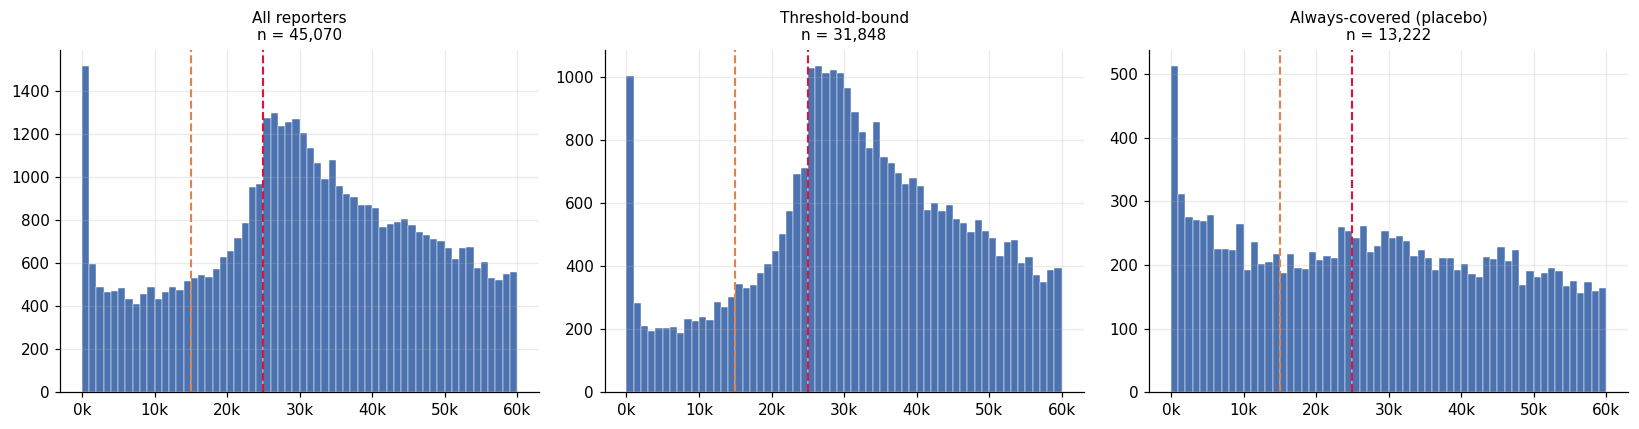

facility-years in the threshold region, by group:


threshold_bound,always-covered,threshold-bound
emissions,,
"(0, 10000]",2636,2678
"(10000, 15000]",1052,1331
"(15000, 20000]",1015,1801
"(20000, 25000]",1149,2928
"(25000, 30000]",1208,5120
"(30000, 50000]",4191,13486


In [5]:
def thr_hist(ax, d, lo, hi, bw, title):
    x = d.loc[d.emissions.between(lo, hi), "emissions"]
    ax.hist(x, bins=np.arange(lo, hi + bw, bw), color="#4C72B0", edgecolor="white", lw=.3)
    ax.axvline(25000, color="crimson", ls="--", lw=1.4)
    ax.axvline(15000, color="#DD8452", ls="--", lw=1.4)
    ax.set_title(f"{title}\nn = {len(x):,}", fontsize=10)
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))


fig, ax = plt.subplots(1, 3, figsize=(15, 4))
thr_hist(ax[0], de, 0, 60000, 1000, "All reporters")
thr_hist(ax[1], de[de.threshold_bound], 0, 60000, 1000, "Threshold-bound")
thr_hist(ax[2], de[de.always_covered], 0, 60000, 1000, "Always-covered (placebo)")
plt.tight_layout(); plt.savefig(OUT / "f3_threshold_region.png", bbox_inches="tight"); plt.show()

print("facility-years in the threshold region, by group:")
display(pd.crosstab(pd.cut(de.emissions, [0, 10000, 15000, 20000, 25000, 30000, 50000]),
                    de.threshold_bound.map({True: "threshold-bound", False: "always-covered"})))

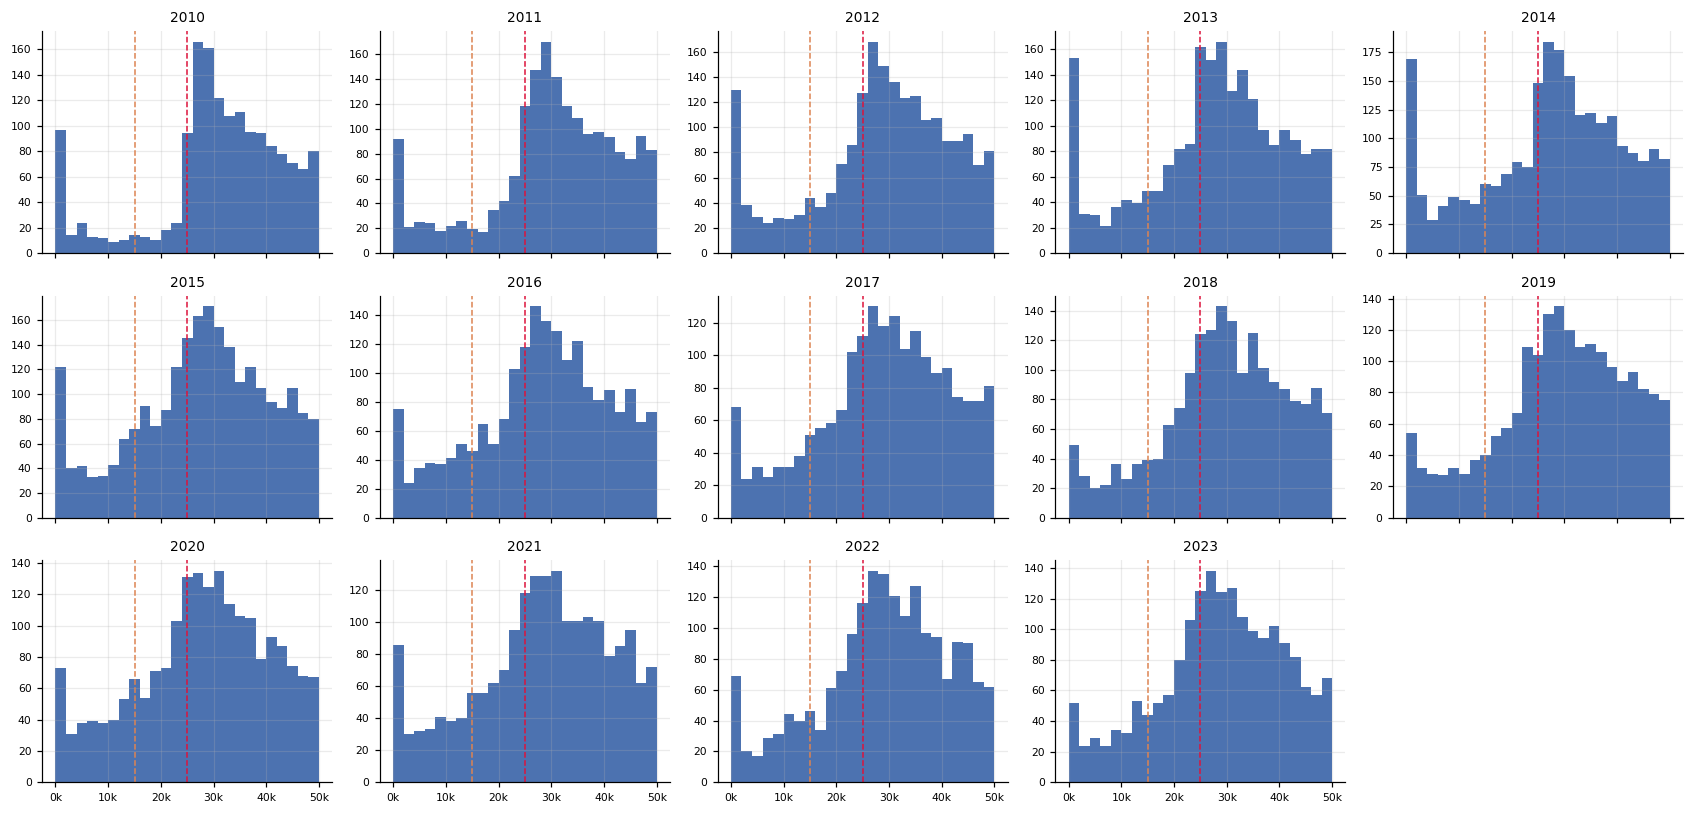

In [6]:
# the same picture year by year — does the shape move, or is it a fixed feature?
yrs = sorted(de.year.unique())
ncol = 5; nrow = int(np.ceil(len(yrs) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.1 * ncol, 2.5 * nrow), sharex=True)
for a, y in zip(axes.ravel(), yrs):
    dd = de[(de.year == y) & de.threshold_bound & de.emissions.between(0, 50000)]
    a.hist(dd.emissions, bins=np.arange(0, 51000, 2000), color="#4C72B0")
    a.axvline(25000, color="crimson", ls="--", lw=1); a.axvline(15000, color="#DD8452", ls="--", lw=1)
    a.set_title(y, fontsize=9); a.tick_params(labelsize=7)
    a.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))
for a in axes.ravel()[len(yrs):]: a.axis("off")
plt.tight_layout(); plt.savefig(OUT / "f4_threshold_by_year.png", bbox_inches="tight"); plt.show()

The shape is **identical in every year of the panel**, including years with no policy
activity at all. A behavioural response would be expected to vary with the salience of
climate policy; a truncation artefact would not. This is a weak test on its own, but it
points the same way as everything in notebook 01.

## ★ The structural fact this project has to live with

Look at the middle panel. Threshold-bound facilities show a sharp edge at 25,000 and a
tall bar immediately above it. **That is not behaviour.** Those facilities are absent
from the data below the line because they do not report. Firm size is right-skewed, so
observed density is *mechanically* highest just above any truncation point.

> **Classic bunching is therefore not identified at this threshold.** There is no
> observed counterfactual density below the cutoff to compare against.

This is the single most consequential fact in the project and it is why:

- **notebook 01** shows both obvious designs failing, and formalises the truncation
  argument with the always-covered group (which is *not* truncated);
- **notebook 02** moves the test into **growth-rate space**, where both sides of the
  cutoff are observed, and then to **California and Washington**, which require
  reporting from 10,000 and so observe the region the federal data cannot;
- **notebook 03** abandons manipulation altogether and uses the 98.2(i) exit instead.

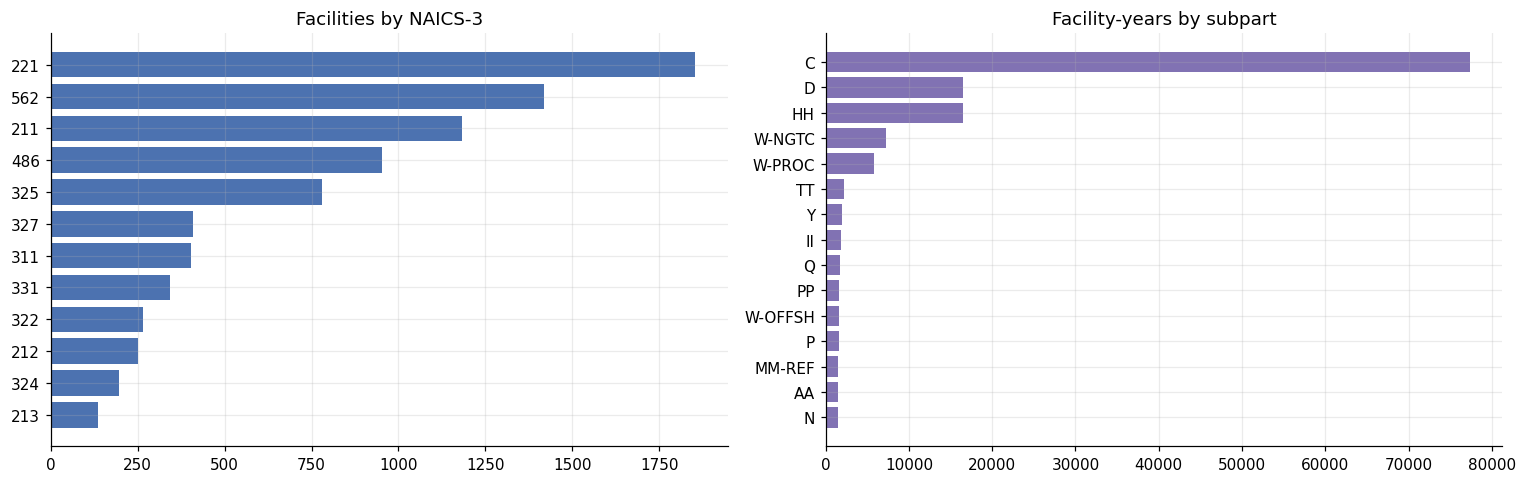


who actually sits near the threshold:


,size,median,share_lt25k
naics3,,,
221,20554,246635.272,0.174
562,17413,54487.250,0.211
325,9151,85867.876,0.086
211,8926,50558.015,0.164
486,8670,39819.368,0.233
327,4843,94327.844,0.063
311,4605,44703.432,0.100
331,3838,73523.073,0.101
322,3178,112212.795,0.064


In [7]:
top = de.groupby("naics3").FacilityId.nunique().sort_values(ascending=False).head(12)
sub = de.subpart_set.explode().value_counts().head(15)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].barh(top.index[::-1].astype(str), top.values[::-1], color="#4C72B0")
ax[0].set_title("Facilities by NAICS-3")
ax[1].barh(sub.index[::-1].astype(str), sub.values[::-1], color="#8172B3")
ax[1].set_title("Facility-years by subpart")
plt.tight_layout(); plt.savefig(OUT / "f7_composition.png", bbox_inches="tight"); plt.show()

print("\nwho actually sits near the threshold:")
display(de.groupby("naics3").emissions
          .agg(["size", "median", lambda s: (s < 25000).mean()])
          .rename(columns={"<lambda_0>": "share_lt25k"})
          .sort_values("size", ascending=False).head(12).round(3))

---
### → Continue in **01_identification**

The next notebook asks whether either of the two designs a reader would reach for first
— bunching at the level cutoff, or always-covered facilities as a counterfactual — can
actually be made to work here. Neither can, and the reason is the same in both cases.